In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score
from sklearn.metrics import homogeneity_completeness_v_measure, silhouette_score
from itertools import cycle, islice
import seaborn as sns

sns.set(style="ticks")
np.random.seed(100)

import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('wine-clustering.csv')
print(df.head())
print(df.info())
print(df.describe())
print("Пропуски:")
print(df.isnull().sum())

   Alcohol  Malic_Acid   Ash  Ash_Alcanity  Magnesium  Total_Phenols  \
0    14.23        1.71  2.43          15.6        127           2.80   
1    13.20        1.78  2.14          11.2        100           2.65   
2    13.16        2.36  2.67          18.6        101           2.80   
3    14.37        1.95  2.50          16.8        113           3.85   
4    13.24        2.59  2.87          21.0        118           2.80   

   Flavanoids  Nonflavanoid_Phenols  Proanthocyanins  Color_Intensity   Hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   OD280  Proline  
0   3.92     1065  
1   3.40     1050  
2   3.17     1185  
3   3.45    

In [3]:
# selected_features = ['longitude', 'latitude', 'housing_median_age', 'total_rooms',
#                     'population', 'households', 'median_income']

selected_features = df.columns.tolist()
D1_raw = df[selected_features].copy()

print(f"Датасет D1 (исходный): {D1_raw.shape}")
print(f"Признаки: {list(D1_raw.columns)}")

Датасет D1 (исходный): (178, 13)
Признаки: ['Alcohol', 'Malic_Acid', 'Ash', 'Ash_Alcanity', 'Magnesium', 'Total_Phenols', 'Flavanoids', 'Nonflavanoid_Phenols', 'Proanthocyanins', 'Color_Intensity', 'Hue', 'OD280', 'Proline']


In [4]:
scaler = StandardScaler()
D1 = scaler.fit_transform(D1_raw)

print(f"Размер: {D1.shape}")
print(f"{D1[:5]}")

Размер: (178, 13)
[[ 1.51861254 -0.5622498   0.23205254 -1.16959318  1.91390522  0.80899739
   1.03481896 -0.65956311  1.22488398  0.25171685  0.36217728  1.84791957
   1.01300893]
 [ 0.24628963 -0.49941338 -0.82799632 -2.49084714  0.01814502  0.56864766
   0.73362894 -0.82071924 -0.54472099 -0.29332133  0.40605066  1.1134493
   0.96524152]
 [ 0.19687903  0.02123125  1.10933436 -0.2687382   0.08835836  0.80899739
   1.21553297 -0.49840699  2.13596773  0.26901965  0.31830389  0.78858745
   1.39514818]
 [ 1.69154964 -0.34681064  0.4879264  -0.80925118  0.93091845  2.49144552
   1.46652465 -0.98187536  1.03215473  1.18606801 -0.42754369  1.18407144
   2.33457383]
 [ 0.29570023  0.22769377  1.84040254  0.45194578  1.28198515  0.80899739
   0.66335127  0.22679555  0.40140444 -0.31927553  0.36217728  0.44960118
  -0.03787401]]


In [5]:
pca = PCA(n_components=2)
D2 = pca.fit_transform(D1)

print(f"Размер датасета D2: {D2.shape}")
print(f"Доля объясненной дисперсии: {pca.explained_variance_ratio_}")
print(f"Суммарная доля объясненной дисперсии: {np.sum(pca.explained_variance_ratio_):.4f}")
print(f"Первые 5 точек в пространстве:{D2[:5]}")

Размер датасета D2: (178, 2)
Доля объясненной дисперсии: [0.36198848 0.1920749 ]
Суммарная доля объясненной дисперсии: 0.5541
Первые 5 точек в пространстве:[[ 3.31675081  1.44346263]
 [ 2.20946492 -0.33339289]
 [ 2.51674015  1.0311513 ]
 [ 3.75706561  2.75637191]
 [ 1.00890849  0.86983082]]


In [6]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
D3 = tsne.fit_transform(D1)

print(f"Размер датасета D3: {D3.shape}")
print(f"Первые 5 точек в пространстве t-SNE:{D3[:5]}")

Размер датасета D3: (178, 2)
Первые 5 точек в пространстве t-SNE:[[10.9068365 -6.368669 ]
 [ 7.162088  -5.6288743]
 [ 7.936114  -9.866809 ]
 [10.758796  -9.173645 ]
 [ 3.8357487 -9.728746 ]]


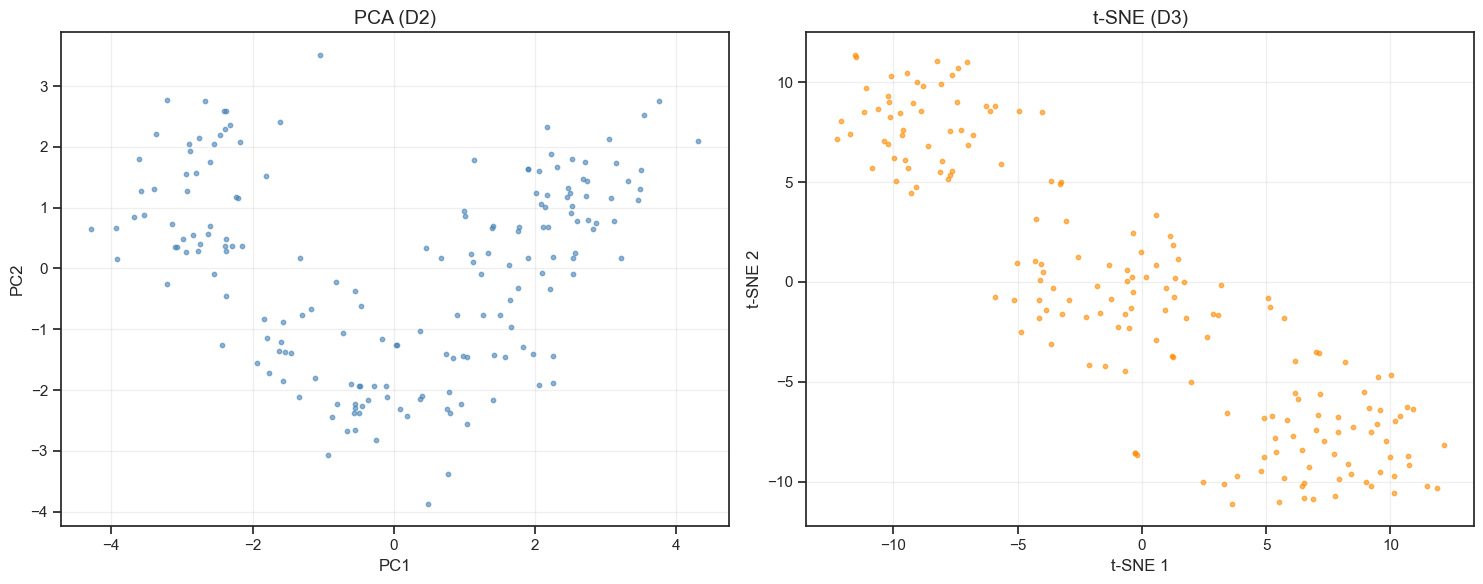

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].scatter(D2[:, 0], D2[:, 1], s=10, alpha=0.6, c='steelblue')
axes[0].set_title('PCA (D2)', fontsize=14)
axes[0].set_xlabel('PC1', fontsize=12)
axes[0].set_ylabel('PC2', fontsize=12)
axes[0].grid(alpha=0.3)

axes[1].scatter(D3[:, 0], D3[:, 1], s=10, alpha=0.6, c='darkorange')
axes[1].set_title('t-SNE (D3)', fontsize=14)
axes[1].set_xlabel('t-SNE 1', fontsize=12)
axes[1].set_ylabel('t-SNE 2', fontsize=12)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
def clustering(X, dataset_name):
    results = []
    print(f"K-MEANS")

    best_k = 3
    best_sil = -1
    
    for k in range(2, 7):
        kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels_temp = kmeans_temp.fit_predict(X)
        if len(np.unique(labels_temp)) > 1:
            sil_temp = silhouette_score(X, labels_temp)
            if sil_temp > best_sil:
                best_sil = sil_temp
                best_k = k
    
    print(f"   Оптимальное k по silhouette: {best_k}")
    kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
    labels_kmeans = kmeans.fit_predict(X)
    sil_kmeans = silhouette_score(X, labels_kmeans)
    
    print(f"   Количество кластеров: {len(np.unique(labels_kmeans))}")
    print(f"   Silhouette Score: {sil_kmeans:.4f}")
    
    print("AGGLOMERATIVE CLUSTERING:")
    best_k_agg = 3
    best_sil_agg = -1
    
    for k in range(2, 7):
        agg_temp = AgglomerativeClustering(n_clusters=k)
        labels_temp = agg_temp.fit_predict(X)
        if len(np.unique(labels_temp)) > 1:
            sil_temp = silhouette_score(X, labels_temp)
            if sil_temp > best_sil_agg:
                best_sil_agg = sil_temp
                best_k_agg = k
    
    print(f"   Оптимальное k по silhouette: {best_k_agg}")
    agg = AgglomerativeClustering(n_clusters=best_k_agg)
    labels_agg = agg.fit_predict(X)
    sil_agg = silhouette_score(X, labels_agg)
    
    print(f"   Количество кластеров: {len(np.unique(labels_agg))}")
    print(f"   Silhouette Score: {sil_agg:.4f}")

    print("GAUSSIAN MIXTURE MODEL (GMM):")
    best_k_gmm = 3
    best_sil_gmm = -1
    best_bic = np.inf
    
    for k in range(2, 7):
        gmm_temp = GaussianMixture(n_components=k, random_state=42, n_init=10)
        gmm_temp.fit(X)
        labels_temp = gmm_temp.predict(X)
        bic_temp = gmm_temp.bic(X)
        
        if len(np.unique(labels_temp)) > 1:
            sil_temp = silhouette_score(X, labels_temp)
            if sil_temp > best_sil_gmm:
                best_sil_gmm = sil_temp
                best_k_gmm = k
                best_bic = bic_temp
    
    print(f"   Оптимальное k по silhouette: {best_k_gmm}")
    print(f"   BIC (Bayesian Information Criterion): {best_bic:.2f}")
    
    gmm = GaussianMixture(n_components=best_k_gmm, random_state=42, n_init=10)
    labels_gmm = gmm.fit_predict(X)
    sil_gmm = silhouette_score(X, labels_gmm)
    
    print(f"   Количество кластеров: {len(np.unique(labels_gmm))}")
    print(f"   Silhouette Score: {sil_gmm:.4f}")
    
    methods = ['K-Means', 'Agglomerative', 'GMM']
    silhouettes = [sil_kmeans, sil_agg, sil_gmm]
    labels_list = [labels_kmeans, labels_agg, labels_gmm]
    n_clusters_list = [len(np.unique(labels_kmeans)), len(np.unique(labels_agg)), len(np.unique(labels_gmm))]
    
    for method, sil, n_clust, labels in zip(methods, silhouettes, n_clusters_list, labels_list):
        results.append({
            'Датасет': dataset_name,
            'Метод': method,
            'Число кластеров': n_clust,
            'Silhouette': sil
        })
    
    return results, labels_kmeans, labels_agg, labels_gmm

results_D1, lk_d1, la_d1, lg_d1 = clustering(D1, "D1 (исх)")
results_D2, lk_d2, la_d2, lg_d2 = clustering(D2, "D2 (PCA)")
results_D3, lk_d3, la_d3, lg_d3 = clustering(D3, "D3 (t-SNE)")


K-MEANS
   Оптимальное k по silhouette: 3
   Количество кластеров: 3
   Silhouette Score: 0.2849
AGGLOMERATIVE CLUSTERING:
   Оптимальное k по silhouette: 3
   Количество кластеров: 3
   Silhouette Score: 0.2774
GAUSSIAN MIXTURE MODEL (GMM):
   Оптимальное k по silhouette: 3
   BIC (Bayesian Information Criterion): 5806.29
   Количество кластеров: 3
   Silhouette Score: 0.2844
K-MEANS
   Оптимальное k по silhouette: 3
   Количество кластеров: 3
   Silhouette Score: 0.5611
AGGLOMERATIVE CLUSTERING:
   Оптимальное k по silhouette: 3
   Количество кластеров: 3
   Silhouette Score: 0.5591
GAUSSIAN MIXTURE MODEL (GMM):
   Оптимальное k по silhouette: 3
   BIC (Bayesian Information Criterion): 1313.38
   Количество кластеров: 3
   Silhouette Score: 0.5581
K-MEANS
   Оптимальное k по silhouette: 3
   Количество кластеров: 3
   Silhouette Score: 0.6043
AGGLOMERATIVE CLUSTERING:
   Оптимальное k по silhouette: 3
   Количество кластеров: 3
   Silhouette Score: 0.5771
GAUSSIAN MIXTURE MODEL (GMM)

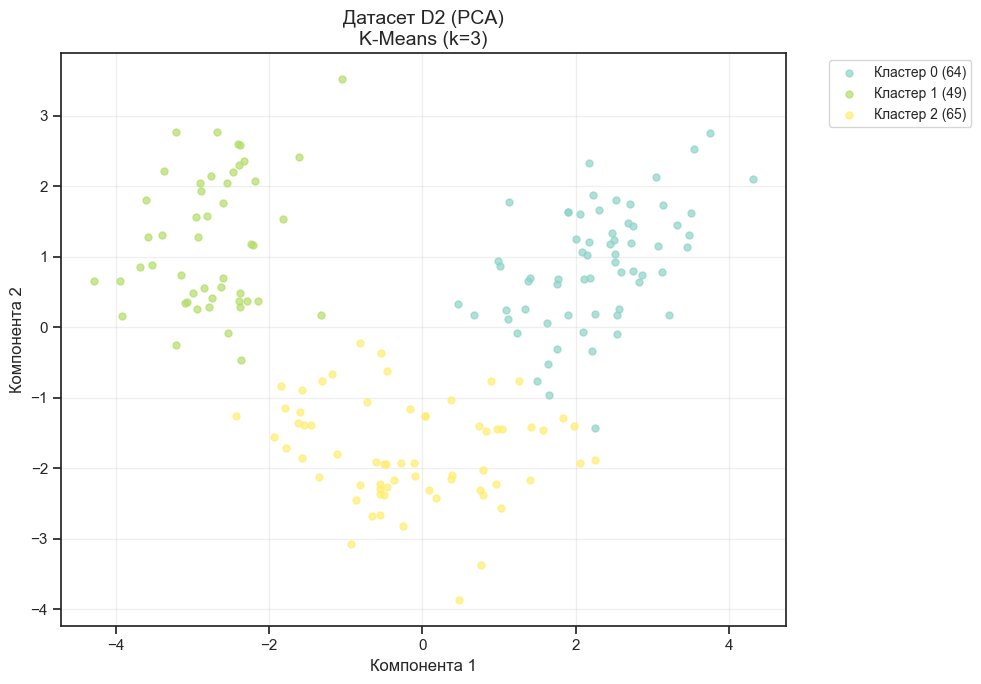

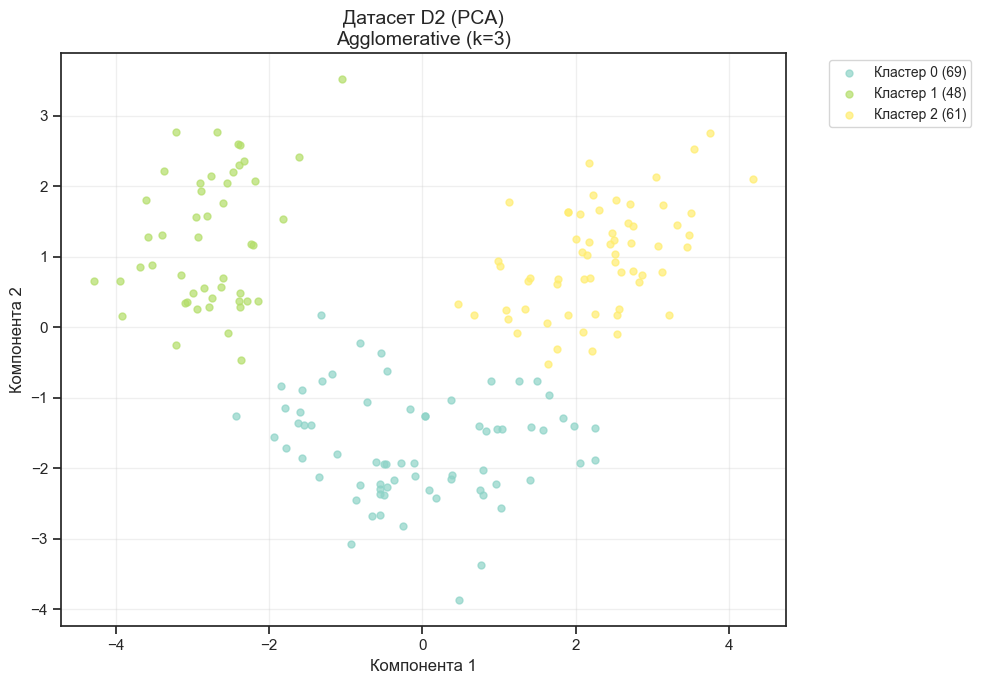

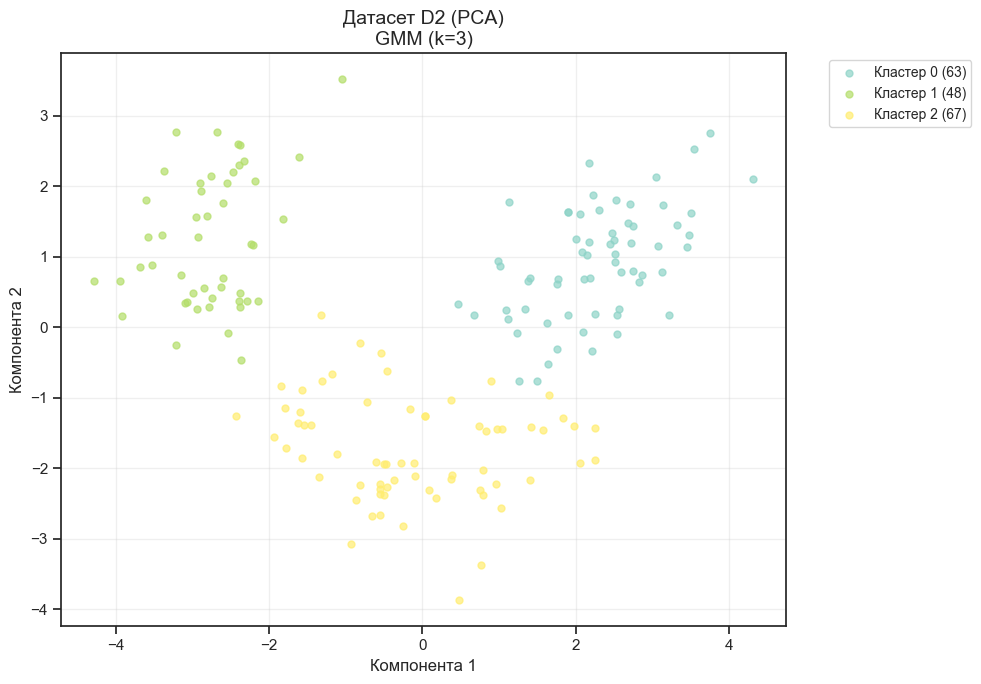

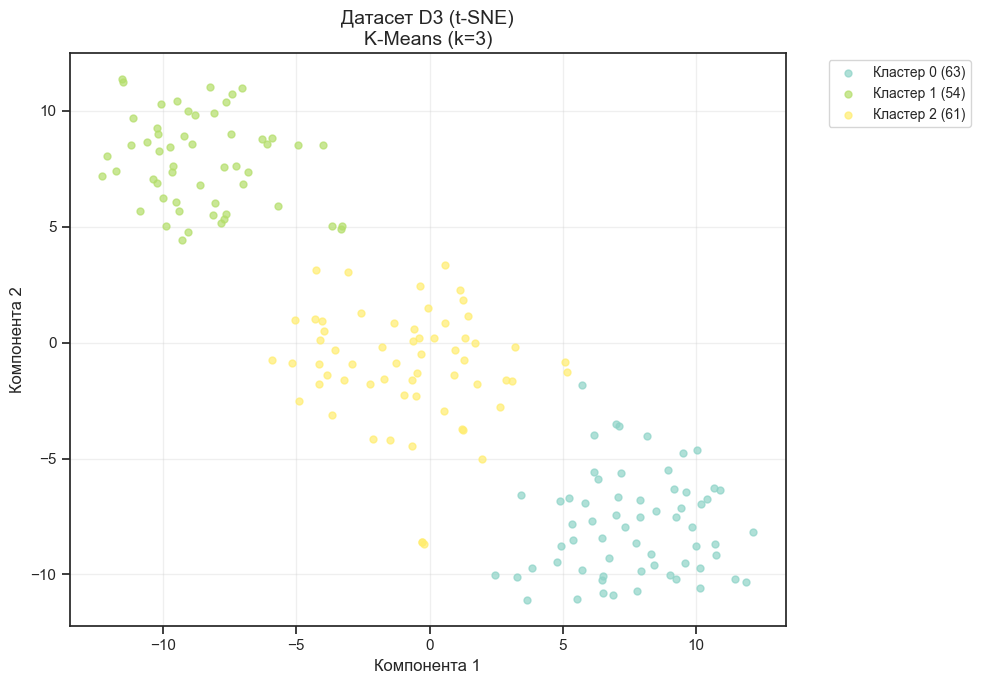

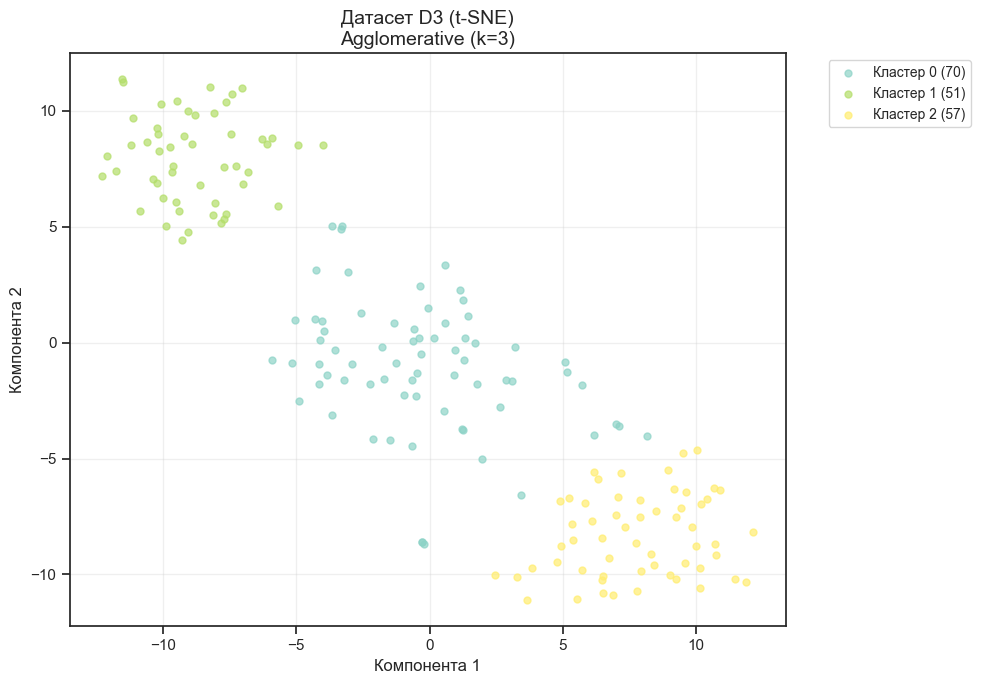

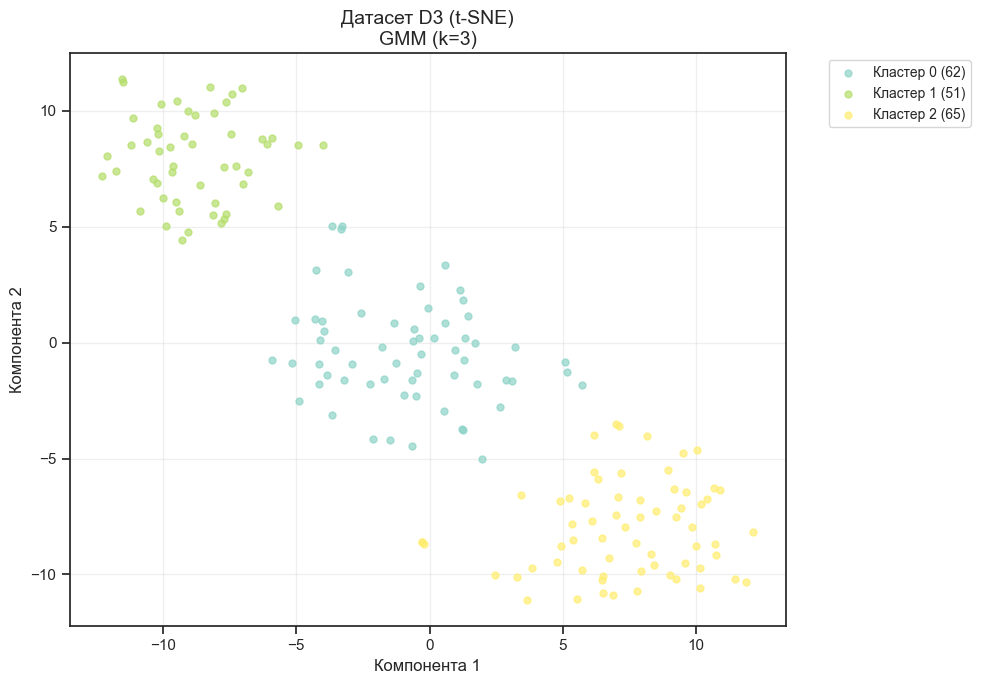

In [9]:
def plot_clustering_results(data, labels, title, method_name):
    plt.figure(figsize=(10, 7))
    
    unique_labels = np.unique(labels)
    n_clusters = len(unique_labels)
    
    colors = plt.cm.Set3(np.linspace(0, 1, n_clusters))
    
    for i, label in enumerate(unique_labels):
        mask = labels == label
        plt.scatter(data[mask, 0], data[mask, 1], 
                   s=25, color=colors[i], alpha=0.7, 
                   label=f'Кластер {label} ({np.sum(mask)})')
    
    plt.title(f'{title}\n{method_name}', fontsize=14)
    plt.xlabel('Компонента 1', fontsize=12)
    plt.ylabel('Компонента 2', fontsize=12)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_clustering_results(D2, lk_d2, 'Датасет D2 (PCA)', f'K-Means (k={len(np.unique(lk_d2))})')
plot_clustering_results(D2, la_d2, 'Датасет D2 (PCA)', f'Agglomerative (k={len(np.unique(la_d2))})')
plot_clustering_results(D2, lg_d2, 'Датасет D2 (PCA)', f'GMM (k={len(np.unique(lg_d2))})')

plot_clustering_results(D3, lk_d3, 'Датасет D3 (t-SNE)', f'K-Means (k={len(np.unique(lk_d3))})')
plot_clustering_results(D3, la_d3, 'Датасет D3 (t-SNE)', f'Agglomerative (k={len(np.unique(la_d3))})')
plot_clustering_results(D3, lg_d3, 'Датасет D3 (t-SNE)', f'GMM (k={len(np.unique(lg_d3))})')

In [ ]:
all_results = []
all_results.extend(results_D1)
all_results.extend(results_D2)
all_results.extend(results_D3)

results_df = pd.DataFrame(all_results)

display_cols = ['Датасет', 'Метод', 'Число кластеров', 'Silhouette']

extra_cols = ['ARI', 'AMI', 'V-measure']
for col in extra_cols:
    if col in results_df.columns and results_df[col].notna().any():
        display_cols.append(col)

print(results_df[display_cols].round(4).to_string(index=False))

for dataset in ['D1 (исх)', 'D2 (PCA)', 'D3 (t-SNE)']:
    print(f"\n{dataset}:")
    subset = results_df[results_df['Датасет'] == dataset]
    
    if len(subset) > 0:  
        for _, row in subset.iterrows():
            print(f"  {row['Метод']:15s}: Silhouette = {row['Silhouette']:.4f}")
        
        valid_subset = subset[subset['Silhouette'] > -1]
        if len(valid_subset) > 0:
            best = valid_subset.loc[valid_subset['Silhouette'].idxmax()]
            print(f"  {'Лучший метод':15s}: {best['Метод']} (Silhouette = {best['Silhouette']:.4f})")
        else:
            print(f"  {'Лучший метод':15s}: Нет валидных результатов")
    else:
        print(f"  Нет данных для {dataset}")

   Датасет         Метод  Число кластеров  Silhouette
  D1 (исх)       K-Means                3      0.2849
  D1 (исх) Agglomerative                3      0.2774
  D1 (исх)           GMM                3      0.2844
  D2 (PCA)       K-Means                3      0.5611
  D2 (PCA) Agglomerative                3      0.5591
  D2 (PCA)           GMM                3      0.5581
D3 (t-SNE)       K-Means                3      0.6043
D3 (t-SNE) Agglomerative                3      0.5771
D3 (t-SNE)           GMM                3      0.6056

D1 (исх):
  K-Means        : Silhouette = 0.2849
  Agglomerative  : Silhouette = 0.2774
  GMM            : Silhouette = 0.2844
  Лучший метод   : K-Means (Silhouette = 0.2849)

D2 (PCA):
  K-Means        : Silhouette = 0.5611
  Agglomerative  : Silhouette = 0.5591
  GMM            : Silhouette = 0.5581
  Лучший метод   : K-Means (Silhouette = 0.5611)

D3 (t-SNE):
  K-Means        : Silhouette = 0.6043
  Agglomerative  : Silhouette = 0.5771
  GMM          